In [1]:
# from netCDF4 import Dataset
import numpy as np
import xarray as xr
import tensorflow as tf
# from tensorflow.keras.layers import Conv3D, MaxPooling3D, UpSampling3D, Dense, Flatten, Conv3DTranspose, Softmax
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

C:\Users\decis\anaconda3\envs\kaveh_tensorflow\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [ ]:
# Set NumPy to display the full array
# np.set_printoptions(threshold=np.inf)  # Show entire array, no truncation

In [3]:
# https://drive.google.com/file/d/1od-TIaU_oFTKZZEXsvOglM5Qqz3c6CV8/view?usp=drive_link
# https://drive.google.com/file/d/113t5V1yFetinTzClFCsIJU3JqdM9uIeh/view?usp=sharing, 
# https://drive.google.com/file/d/1MT26XfWRrGYFq4OmYvlVa8tvYm_vWRs5/view?usp=sharing, 
# https://drive.google.com/file/d/1ZAt95Bac_GNrsI3-eKg6QJIlVK6CSwgM/view?usp=sharing, 
# https://drive.google.com/file/d/1t7g4sm_Ri_99t9okGi0tgcAJvUQ7YTTk/view?usp=sharing, 
# https://drive.google.com/file/d/1u1O2ccFdpXdMGMVIA0Ew2mPHOnoTfYLg/view?usp=sharing
# https://drive.google.com/file/d/15ed4H3X9Q0RC9C0Ke_USmrcjNnhtX3A_/view?usp=sharing
# url = 'https://drive.google.com/uc?id=1od-TIaU_oFTKZZEXsvOglM5Qqz3c6CV8'

# # Download the file
# !gdown {url}
# url = 'https://drive.google.com/uc?id=113t5V1yFetinTzClFCsIJU3JqdM9uIeh'

# # Download the file
# !gdown {url}
# url = 'https://drive.google.com/uc?id=1MT26XfWRrGYFq4OmYvlVa8tvYm_vWRs5'

# # Download the file
# !gdown {url}
# url = 'https://drive.google.com/uc?id=1ZAt95Bac_GNrsI3-eKg6QJIlVK6CSwgM'

# # Download the file
# https://drive.google.com/file/d/1VmuYn1ck5_KQQTS5dSLByKT-yg88610S/view?usp=sharing
# !gdown {url}
url = 'https://drive.google.com/uc?id=1VmuYn1ck5_KQQTS5dSLByKT-yg88610S'

# Download the file
!gdown {url}
# url = 'https://drive.google.com/uc?id=15ed4H3X9Q0RC9C0Ke_USmrcjNnhtX3A_'

# # Download the file
# !gdown {url}

'gdown' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
!unrar x /kaggle/working/NC_2.rar


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /kaggle/working/NC_2.rar

Creating    NC                                                        OK
Extracting  NC/landsat2000.nc                                                  3  OK 
Extracting  NC/landsat2000.nc.aux.xml                                    3  OK 
Extracting  NC/landsat2001.nc                                                  7  OK 
Extracting  NC/landsat2002.nc                                               1 11  OK 
Extracting  NC/landsat2003.nc                                           1 1 1 15  OK 
Extracting  NC/landsat2004.nc                                           1 1 1 19  OK 
Extracting  NC/landsat2005.nc                                           2 2 2 23  OK 
Extracting  NC/landsat2006.nc                                           2 2 2 27  OK 
Extracting  NC/landsat2007.nc                                           2 2 3 31  OK 
Extracting  NC/landsat2008.nc            

In [6]:
!unrar x /kaggle/working/nc_ndvi_dem_slope_distances.rar


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /kaggle/working/nc_ndvi_dem_slope_distances.rar

Creating    nc_ndvi_dem_slope_distances                               OK
Extracting  nc_ndvi_dem_slope_distances/dem.nc                           0  OK 
Extracting  nc_ndvi_dem_slope_distances/dem.nc.aux.xml                   0  OK 
Extracting  nc_ndvi_dem_slope_distances/ndvi2000.nc                      4  OK 
Extracting  nc_ndvi_dem_slope_distances/ndvi2001.nc                        8  OK 
Extracting  nc_ndvi_dem_slope_distances/ndvi2002.nc                     1 12  OK 
Extracting  nc_ndvi_dem_slope_distances/ndvi2003.nc                     15  OK 
Extracting  nc_ndvi_dem_slope_distances/ndvi2004.nc                     19  OK 
Extracting  nc_ndvi_dem_slope_distances/ndvi2005.nc                     2 23  OK 
Extracting  nc_ndvi_dem_slope_distances/ndvi2006.nc                     2 27  OK 
Extracting  nc_ndvi_dem_slope_distances/ndvi2007.nc       

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Example: Simulated dataset
# num_samples = 6  # Number of samples
# temporal_depth = 2  # Number of consecutive years as input
# height, width, num_bands = 2240, 2190, 7  # Image dimensions and bands
# num_classes = 5  # Number of discrete classes

In [2]:
import xarray as xr
import numpy as np
import os

# List of NetCDF file paths
file_paths = ['landsat2000.nc', 'landsat2001.nc',
              'landsat2002.nc', 'landsat2003.nc',
              'landsat2004.nc', 'landsat2005.nc',
             'landsat2006.nc', 'landsat2007.nc',
              'landsat2008.nc', 'landsat2009.nc',
              'landsat2010.nc', 'landsat2011.nc',
             'landsat2012.nc', 'landsat2013.nc',
              'landsat2014.nc', 'landsat2015.nc',
              'landsat2016.nc', 'landsat2017.nc',
             'landsat2018.nc', 'landsat2019.nc',
              'landsat2020.nc', 'landsat2021.nc',
              'landsat2022.nc', 'landsat2023.nc',
             'landsat2024.nc']  # Replace with your file paths

# Name of the variable you want to extract
# variable_name = 'band1'  # Replace with the actual variable name

# Initialize an empty list to store NumPy arrays
data_list = []

# Loop through each file, load the variable, and append to the list
for file_path in file_paths:
    temporarial = []
    if os.path.exists(file_path):  # Check if the file exists
        print(f"Loading file: {file_path}")

        # Open the file using xarray
        dataset = xr.open_dataset(file_path)
        dataset = dataset.fillna(0)
        for variable_name in ['Band1', 'Band2', 'Band3', 'Band4', 'Band5']:#, 'band6', 'band7']:
            # Extract the variable as a NumPy array and append to the list
            data_array = dataset[variable_name].values  # Extract data as NumPy array
            temporarial.append(data_array)
            # print(f"Shape of data from {file_path}: {data_array.shape}")
    data_list.append(temporarial)



# At this point, 'combined_data' contains all the concatenated data.


Loading file: landsat2000.nc
Loading file: landsat2001.nc
Loading file: landsat2002.nc
Loading file: landsat2003.nc
Loading file: landsat2004.nc
Loading file: landsat2005.nc
Loading file: landsat2006.nc
Loading file: landsat2007.nc
Loading file: landsat2008.nc
Loading file: landsat2009.nc
Loading file: landsat2010.nc
Loading file: landsat2011.nc
Loading file: landsat2012.nc
Loading file: landsat2013.nc
Loading file: landsat2014.nc
Loading file: landsat2015.nc
Loading file: landsat2016.nc
Loading file: landsat2017.nc
Loading file: landsat2018.nc
Loading file: landsat2019.nc
Loading file: landsat2020.nc
Loading file: landsat2021.nc
Loading file: landsat2022.nc
Loading file: landsat2023.nc
Loading file: landsat2024.nc


In [3]:
np.array(data_list).shape

(25, 5, 1825, 1867)

In [4]:
final_array = np.array(data_list)

In [5]:
# Reorder axes to (samples, height, width, number_of_channels)
array_reordered = np.transpose(final_array, (0, 2, 3, 1))

In [6]:
array_reordered.shape

(25, 1825, 1867, 5)

In [7]:
def normalize_with_padding_dataset(images):
    """
    Normalizes a dataset of images to the range [0, 1] channel-wise across all samples,
    leaving zero-padding unchanged.

    Args:
        images (numpy.ndarray): Dataset of images with shape (N, H, W, C), where
                                N is the number of samples, H and W are spatial dimensions,
                                and C is the number of channels.

    Returns:
        numpy.ndarray: Normalized dataset with padding (zeros) unchanged.
        list: List of (min, max) values for each channel across the entire dataset.
    """
    # Check the shape of the input array
    if images.ndim != 4:
        raise ValueError("Input dataset must be a 4D array with shape (N, H, W, C).")
    
    # Initialize min-max tracker for each channel
    min_max_values = []
    normalized_images = images.copy()
    
    # Normalize channel-wise across all samples
    for c in range(images.shape[-1]):
        # Extract all channel values across all images
        channel_values = images[:, :, :, c]
        non_zero_mask = channel_values != 0
        
        # Compute min and max across all non-zero values for the channel
        arr_min = channel_values[non_zero_mask].min() if non_zero_mask.any() else 0
        arr_max = channel_values[non_zero_mask].max() if non_zero_mask.any() else 1
        
        # Normalize the channel values for all images
        if arr_max > arr_min:  # Avoid division by zero
            normalized_images[:, :, :, c][non_zero_mask] = (
                channel_values[non_zero_mask] - arr_min
            ) / (arr_max - arr_min)
        
        # Save min-max values for the channel
        min_max_values.append((arr_min, arr_max))
    
    return normalized_images, min_max_values

In [8]:
array_reordered,min_max_values = normalize_with_padding_dataset(array_reordered)

In [9]:
array_reordered.max()

np.float32(1.0)

In [10]:
dataset

<xarray.Dataset> Size: 68MB
Dimensions:  (lat: 1825, lon: 1867)
Coordinates:
  * lat      (lat) float64 15kB 2.9 2.9 2.901 2.901 ... 3.391 3.391 3.391 3.392
  * lon      (lon) float64 15kB 101.4 101.4 101.4 101.4 ... 101.9 101.9 101.9
Data variables:
    Band1    (lat, lon) float32 14MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    Band2    (lat, lon) float32 14MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    Band3    (lat, lon) float32 14MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    Band4    (lat, lon) float32 14MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    Band5    (lat, lon) float32 14MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    crs      object 8B b''
Attributes:
    Conventions:  CF-1.5
    GDAL:         GDAL 3.7.2, released 2023/09/05
    history:      Mon Jan 13 04:21:01 2025: GDAL Create( E:\gis2\Klang_River_...

In [11]:
x=dataset["lon"]
y=dataset["lat"]

In [12]:
# x = np.arange(array_reordered[0].shape[1])  # Height indices
# y = np.arange(array_reordered[0].shape[0])  # Width indices

In [13]:
# Band names
band_names = [f"Band{i+1}" for i in range(5)]

# Create a dictionary to store each band as a separate variable
data_vars = {
    band_names[i]: (["lat", "lon"], array_reordered[0][:, :, i]) for i in range(5)
}

In [14]:
# Create an xarray Dataset
ds = xr.Dataset(
    {
        band_names[i]: (["lat", "lon"], array_reordered[0][:, :, i]) for i in range(5)
    },
    coords={
        "lat": x,  # Spatial x-coordinates
        "lon": y,  # Spatial y-coordinates
    }
)

In [15]:
x = ds['lat']
y = ds['lon']

In [17]:
import matplotlib.pyplot as plt

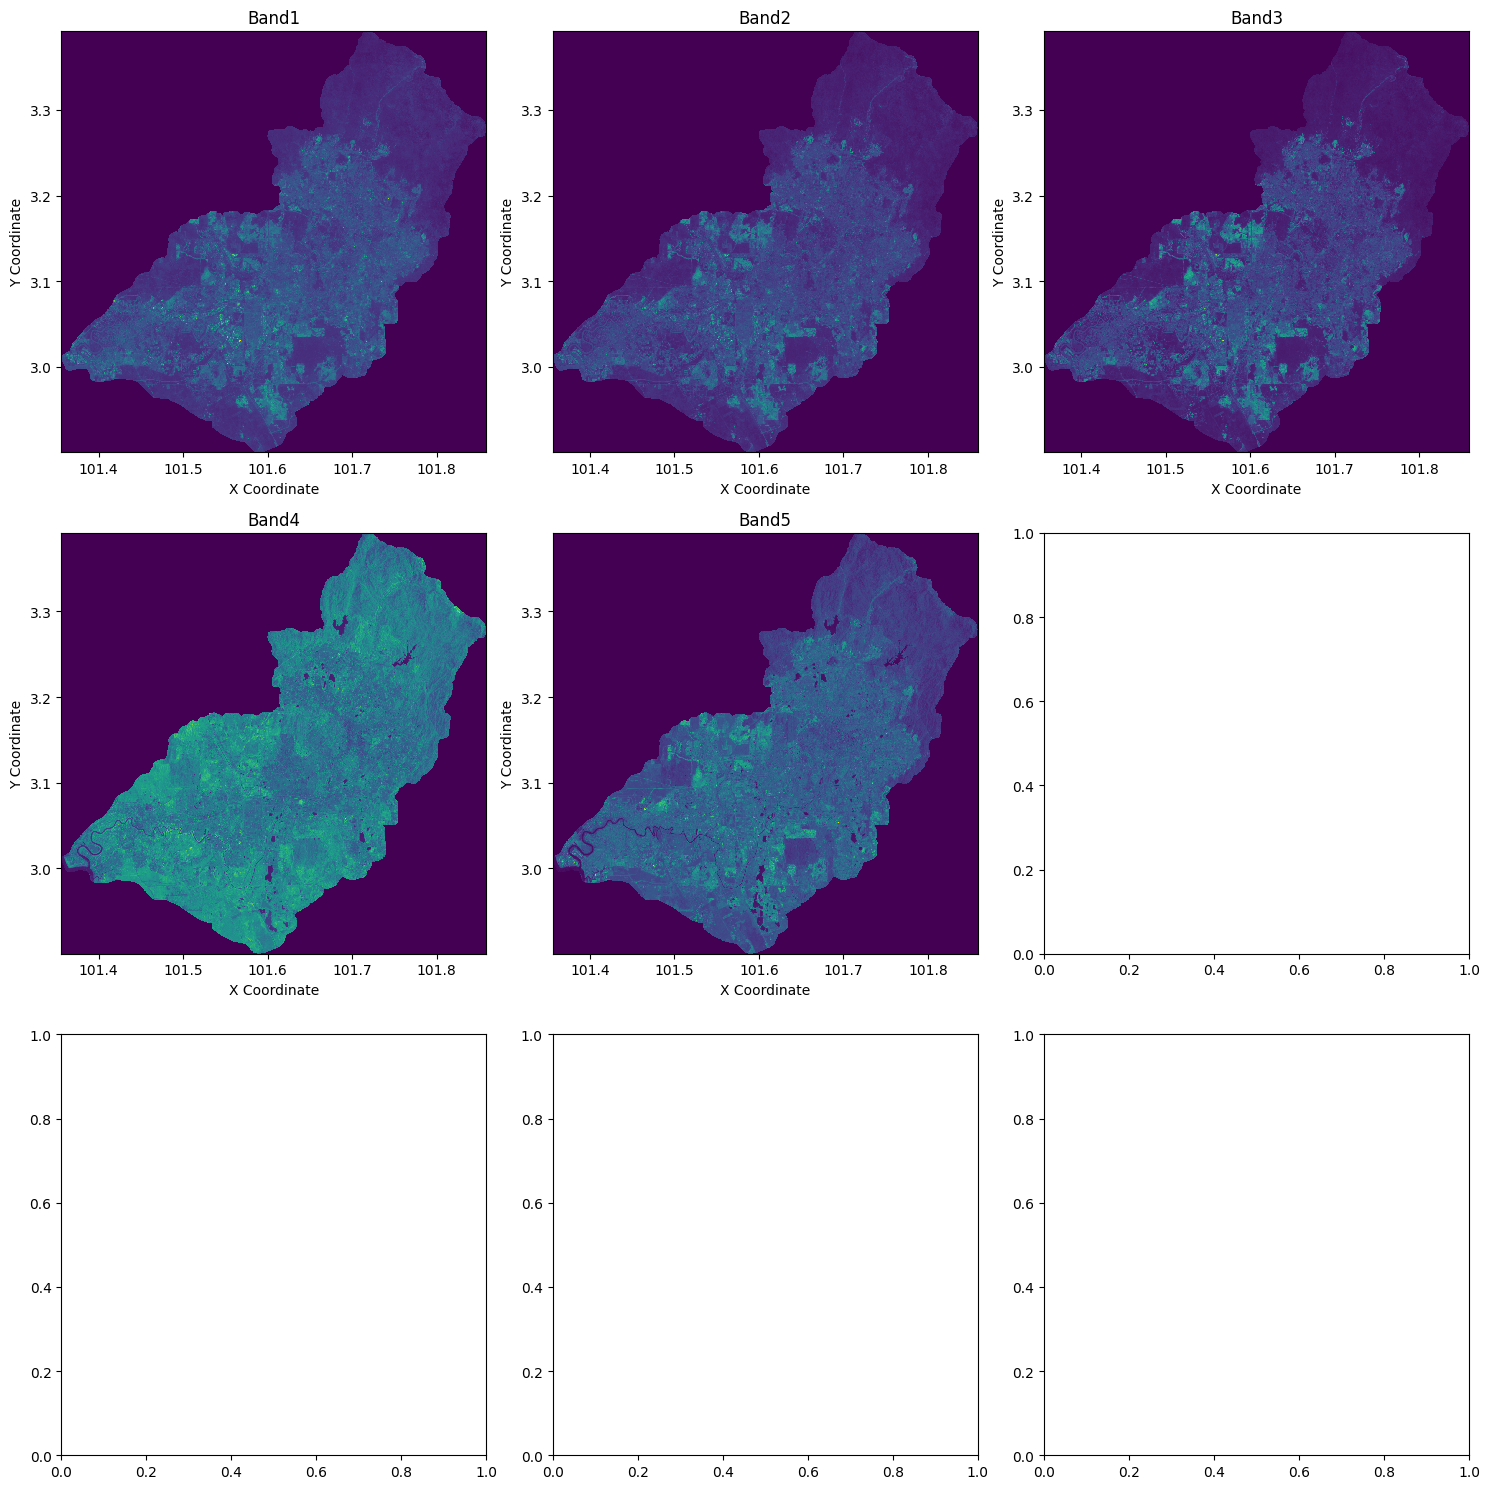

In [18]:
bands = ["Band1", "Band2", "Band3", "Band4", "Band5"]  # Replace with actual names

fig, axes = plt.subplots(3, 3, figsize=(15, 15))  # Adjust grid size as needed
axes = axes.flatten()

for i, band in enumerate(bands):
    if i < len(axes):
        data_band = ds[band]
        axes[i].pcolormesh(x, y, data_band, shading='auto', cmap='viridis')
        axes[i].set_title(band)
        axes[i].set_xlabel("X Coordinate")
        axes[i].set_ylabel("Y Coordinate")

plt.tight_layout()
plt.show()

In [19]:
import numpy as np

def preprocess_netcdf_data(data, num_frames=2):
    """
    Prepares data for training a Conv3D model with temporal input sequences.

    Args:
        data (numpy.ndarray): The input data of shape (num_timesteps, height, width, channels).
        num_frames (int): Number of input frames for each sequence.

    Returns:
        X (numpy.ndarray): Input sequences of shape (num_samples, num_frames, height, width, channels).
        y (numpy.ndarray): Target frames of shape (num_samples, height, width, channels).
    """
    # Number of time steps in the data
    num_timesteps, height, width, channels = data.shape

    # Create input (X) and target (y) sequences
    X = []
    y = []

    for i in range(num_timesteps - num_frames):
        X.append(data[i:i + num_frames])  # Take 'num_frames' consecutive frames as input
        y.append(data[i + num_frames])   # The next frame as target

    # Convert to NumPy arrays
    X = np.array(X)  # Shape: (num_samples, num_frames, height, width, channels)
    y = np.array(y)  # Shape: (num_samples, height, width, channels)

    return X, y

In [20]:
X, y = preprocess_netcdf_data(array_reordered[:], num_frames=1)

In [21]:
X = np.squeeze(X)

In [22]:
X.shape

(24, 1825, 1867, 5)

In [23]:
y.shape

(24, 1825, 1867, 5)

In [24]:
def extract_kernels_to_numpy(images, kernel_size=3, output_file="kernel_data.npy"):
    """
    Extract 3x3 kernels and store them as a NumPy array of shape (n, 9*channels).

    Parameters:
        images (numpy.ndarray): Input array of shape (samples, height, width, channels).
        kernel_size (int): Size of the kernel (default is 3).
        output_file (str): Filepath to save the output NumPy array.

    Returns:
        None: Saves the result as a .npy file.
    """
    pad = kernel_size // 2

    # Padding the images to handle border pixels
    padded_images = np.pad(images, ((0, 0), (pad, pad), (pad, pad), (0, 0)), mode='constant')

    # Get the total number of kernels for preallocation
    num_images, height, width, channels = images.shape
    num_kernels = num_images * height * width

    # Preallocate a large NumPy matrix for storage
    result_matrix = np.zeros((num_kernels, kernel_size * kernel_size * channels), dtype=images.dtype)

    # Fill the matrix efficiently
    row = 0
    for img_index in range(padded_images.shape[0]):
        image = padded_images[img_index]
        for i in range(pad, image.shape[0] - pad):
            for j in range(pad, image.shape[1] - pad):
                # Extract the 3x3 kernel for all channels and flatten
                kernel = image[i-pad:i+pad+1, j-pad:j+pad+1, :].flatten()
                # Assign to the result matrix
                result_matrix[row, :] = kernel
                row += 1

    return result_matrix


In [25]:
X_train = extract_kernels_to_numpy(X, kernel_size=3)

In [26]:
X_train.shape

(81774600, 45)

In [27]:
from pathlib import Path
import re

In [28]:
directory="./nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances"

In [29]:
matching_files = []
for file in Path(directory).rglob("*"):  # Recursively iterate over all files
    if file.is_file():  # Ensure it's a file
        try:
            with open(file, "r", errors="ignore") as f:  # Open file safely
                if "ndvi20" in f.read():  # Check for string in file
                    matching_files.append(file)
        except Exception as e:
            print(f"Skipping {file}: {e}")

In [30]:
matching_files

[WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2000.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2001.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2002.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2003.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2004.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2005.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2006.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2007.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2008.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2009.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2010.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_dista

In [31]:
def extract_last_two_numbers(path):
    """Extract the last two numbers from a file path."""
    numbers = re.findall(r'\d+', str(path))  # Find all numbers in the path
    if len(numbers) >= 2:
        return int(numbers[-2]), int(numbers[-1])  # Return the last two numbers
    elif len(numbers) == 1:
        return 0, int(numbers[-1])  # If only one number, assume 0 for the second-to-last
    else:
        return (0, 0)  # Default case if no numbers are found

In [32]:
def sort_paths_by_last_two_numbers(file_paths):
    """Sort file paths based on the last two numbers in the path."""
    return sorted(file_paths, key=extract_last_two_numbers)

In [33]:
sorted_paths = sort_paths_by_last_two_numbers(matching_files)

In [34]:
sorted_paths

[WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2000.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2001.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2002.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2003.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2004.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2005.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2006.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2007.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2008.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2009.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/ndvi2010.nc'),
 WindowsPath('nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_dista

In [35]:
final_vector = []
for file_path in sorted_paths[:-1]:
    data = xr.open_dataset(file_path)
    arr = data["Band1"].fillna(0).values
    flattened_array = arr.reshape(-1,)
    final_vector.extend(flattened_array)

In [36]:
# ndvi_vector = np.array(final_vector)
# ndvi_vector = (ndvi_vector - ndvi_vector.min()) / (ndvi_vector.max() - ndvi_vector.min())
# # Load the NetCDF file
# file_path = "./nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/dem.nc"  # Replace with your NetCDF file path
# data = xr.open_dataset(file_path)
# dem = data["Band1"].fillna(0).values.reshape(-1,)
# # Min-Max Scaling formula
# dem = (dem - dem.min()) / (dem.max() - dem.min())
# # Load the NetCDF file
# file_path = "./nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/road_dis.nc"  # Replace with your NetCDF file path
# data = xr.open_dataset(file_path)
# road_dis = data["Band1"].fillna(0).values.reshape(-1,)
# # Min-Max Scaling formula
# road_dis = (road_dis - road_dis.min()) / (road_dis.max() - road_dis.min())
# # Load the NetCDF file
# file_path = "./nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/slope.nc"  # Replace with your NetCDF file path
# data = xr.open_dataset(file_path)
# slope = data["Band1"].fillna(0).values.reshape(-1,)
# # Min-Max Scaling formula
# slope = (slope - slope.min()) / (slope.max() - slope.min())
# X_test = np.concatenate((X_test,slope.reshape(-1,1),road_dis.reshape(-1,1),dem.reshape(-1,1),ndvi_vector.reshape(-1,1)),axis=1)

In [37]:
ndvi_vector = np.array(final_vector)

In [38]:
# Min-Max Scaling formula
ndvi_vector = (ndvi_vector - ndvi_vector.min()) / (ndvi_vector.max() - ndvi_vector.min())

In [39]:
# Load the NetCDF file
file_path = "./nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/dem.nc"  # Replace with your NetCDF file path
data = xr.open_dataset(file_path)

In [40]:
dem = np.tile(data["Band1"].fillna(0).values.reshape(-1,),24)

In [41]:
# Min-Max Scaling formula
dem = (dem - dem.min()) / (dem.max() - dem.min())

In [42]:
# Load the NetCDF file
file_path = "./nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/road_dis.nc"  # Replace with your NetCDF file path
data = xr.open_dataset(file_path)

In [43]:
road_dis = np.tile(data["Band1"].fillna(0).values.reshape(-1,),24)

In [44]:
# Min-Max Scaling formula
road_dis = (road_dis - road_dis.min()) / (road_dis.max() - road_dis.min())

In [45]:
# Load the NetCDF file
file_path = "./nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/slope.nc"  # Replace with your NetCDF file path
data = xr.open_dataset(file_path)

In [46]:
slope = np.tile(data["Band1"].fillna(0).values.reshape(-1,),24)

In [47]:
# Min-Max Scaling formula
slope = (slope - slope.min()) / (slope.max() - slope.min())

In [48]:
X_train = np.concatenate((X_train,slope.reshape(-1,1),road_dis.reshape(-1,1),dem.reshape(-1,1),ndvi_vector.reshape(-1,1)),axis=1)

In [49]:
X_train.shape

(81774600, 49)

In [50]:
X_train.shape[0] - X_train.shape[0]/24

78367325.0

In [51]:
x_train, X_test = X_train[:78367325],X_train[78367325:]

In [52]:
def extract_pixels_to_numpy(images):
    """
    Extract individual pixels and their channel values, storing them as a NumPy array of shape (n, channels).

    Parameters:
        images (numpy.ndarray): Input array of shape (samples, height, width, channels).
        output_file (str): Filepath to save the output NumPy array.

    Returns:
        None: Saves the result as a .npy file.
    """
    # Get dimensions of the input images
    num_images, height, width, channels = images.shape
    num_pixels = num_images * height * width

    # Preallocate a large NumPy matrix for storage
    result_matrix = np.zeros((num_pixels, channels), dtype=images.dtype)

    # Fill the matrix efficiently
    row = 0
    for img_index in range(num_images):
        image = images[img_index]
        for i in range(height):
            for j in range(width):
                # Extract the pixel values for all channels
                pixel = image[i, j, :]
                # Assign to the result matrix
                result_matrix[row, :] = pixel
                row += 1
    return result_matrix


In [53]:
Y_data = extract_pixels_to_numpy(y)

In [54]:
y_train, y_test = Y_data[:78367325],Y_data[78367325:]

In [55]:
x_train.shape,y_train.shape

((78367325, 49), (78367325, 5))

In [56]:
# # Step 1: Identify zero rows
# zero_row_indices_x_train = np.where(~x_train.any(axis=1))[0]

# # Step 2: Remove zero rows
# non_zero_array_x_train = x_train[x_train.any(axis=1)]

In [57]:
# Remove rows at zero_row_indices from array2
# non_zero_array_y_train = np.delete(y_train, zero_row_indices_x_train, axis=0)

In [58]:
# non_zero_array_x_train.shape,non_zero_array_y_train.shape

In [59]:
# del non_zero_array_x_train

In [60]:
# del non_zero_array_y_train

In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [62]:
x_train = np.expand_dims(x_train,axis=1)

In [63]:
X_test = np.expand_dims(X_test,axis=1)

In [64]:
# non_zero_array_x_train.shape

In [65]:
# Define the input shape
# input_layer = Input(shape=(1, non_zero_array_x_train.shape[2]))

# # LSTM layer with return_sequences=True to capture hidden states
# lstm_layer = LSTM(50, activation='relu', return_sequences=True, return_state=True)

# # Pass input through LSTM
# lstm_output, hidden_state, cell_state = lstm_layer(input_layer)

# # Add a Dense layer for the final LSTM predictions
# dense_layer = Dense(7)(hidden_state)

# # Define the model
# model = Model(inputs=input_layer, outputs=dense_layer)

# Compile the model
# lstm_model.compile(optimizer='adam', loss='mse')

In [66]:
num_samples = 1000
timesteps = 10
features = 5


# Define the model
model = Sequential([
    LSTM(32, input_shape=(1, x_train.shape[2])),  # LSTM layer with 32 units
    Dense(16, activation='relu'),                # Dense layer with 16 units
    Dense(5, activation='sigmoid')               # Output layer for binary classification
])

C:\Users\decis\anaconda3\envs\kaveh_tensorflow\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [67]:
# Compile the model
model.compile(optimizer='adam', loss='huber', metrics=['mae'])

# Train the model on GPU (this will happen automatically if GPU is enabled in Colab)
model.fit(x_train, y_train, epochs=5, batch_size=1024, validation_data=(X_test, y_test))

Epoch 1/5
76531/76531 ━━━━━━━━━━━━━━━━━━━━ 574s 7ms/step - loss: 2.7031e-04 - mae: 0.0081 - val_loss: 1.0659e-04 - val_mae: 0.0069
Epoch 2/5
76531/76531 ━━━━━━━━━━━━━━━━━━━━ 621s 7ms/step - loss: 1.5331e-04 - mae: 0.0069 - val_loss: 1.0021e-04 - val_mae: 0.0066
Epoch 3/5
76531/76531 ━━━━━━━━━━━━━━━━━━━━ 620s 7ms/step - loss: 1.5156e-04 - mae: 0.0069 - val_loss: 9.9648e-05 - val_mae: 0.0065
Epoch 4/5
76531/76531 ━━━━━━━━━━━━━━━━━━━━ 619s 7ms/step - loss: 1.5058e-04 - mae: 0.0068 - val_loss: 9.8553e-05 - val_mae: 0.0065
Epoch 5/5
76531/76531 ━━━━━━━━━━━━━━━━━━━━ 625s 7ms/step - loss: 1.4999e-04 - mae: 0.0068 - val_loss: 9.8075e-05 - val_mae: 0.0065


In [68]:
def reconstruct_image_from_numpy(pixel_data, original_shape):
    """
    Reconstruct the original image from a flattened pixel data array.

    Parameters:
        pixel_data (numpy.ndarray): Input array of shape (n, channels).
        original_shape (tuple): The original shape of the image array (samples, height, width, channels).

    Returns:
        numpy.ndarray: Reconstructed image array with the original shape.
    """
    # Ensure the total number of pixels matches
    expected_pixels = original_shape[0] * original_shape[1] * original_shape[2]
    if pixel_data.shape[0] != expected_pixels:
        raise ValueError("The number of pixels in the pixel data does not match the original image shape.")

    # Reshape the pixel data to the original image shape
    reconstructed_image = pixel_data.reshape(original_shape)
    return reconstructed_image

In [69]:
y_pred = model.predict(X_test)

106478/106478 ━━━━━━━━━━━━━━━━━━━━ 204s 2ms/step


In [70]:
# Define the original shape of the images (samples, height, width, channels)
original_shape = (1, 1825, 1867, 5)

# Reconstruct the image
reconstructed_images = reconstruct_image_from_numpy(y_pred, original_shape)

In [71]:
pred_original_shape = np.squeeze(reconstructed_images)

In [72]:
pred_original_shape.shape

(1825, 1867, 5)

In [73]:
def denormalize_dataset(normalized_images, min_max_values):
    """
    Denormalizes a dataset of images from the range [0, 1] channel-wise to the original scale.

    Args:
        normalized_images (numpy.ndarray): Normalized dataset with shape (N, H, W, C).
        min_max_values (list): List of (min, max) tuples for each channel.

    Returns:
        numpy.ndarray: Denormalized dataset with the original scale restored.
    """
    # Check the shape of the input array
    if normalized_images.ndim != 4:
        raise ValueError("Input dataset must be a 4D array with shape (N, H, W, C).")
    
    if len(min_max_values) != normalized_images.shape[-1]:
        raise ValueError("Length of min_max_values must match the number of channels in the dataset.")
    
    # Initialize the output array
    denormalized_images = normalized_images.copy()
    
    # Denormalize each channel across all images
    for c in range(normalized_images.shape[-1]):
        channel_values = normalized_images[:, :, :, c]
        arr_min, arr_max = min_max_values[c]
        
        # Reverse the normalization
        if arr_max > arr_min:  # Avoid division by zero
            denormalized_images[:, :, :, c] = channel_values * (arr_max - arr_min) + arr_min
    
    return denormalized_images

In [74]:
# Rescale normalized arrays back to their original values
y_rescaled = denormalize_dataset(reconstructed_images, min_max_values)

In [75]:
y_rescaled.shape

(1, 1825, 1867, 5)

In [76]:
y_rescaled = np.squeeze(y_rescaled)

In [77]:
y_rescaled.shape

(1825, 1867, 5)

In [94]:
y_rescaled

array([[[0.06671415, 0.04245365, 0.02656678, 0.02440188, 0.00644354],
        [0.06671415, 0.04245363, 0.02656675, 0.02440188, 0.00644354],
        [0.06671415, 0.04245361, 0.02656672, 0.02440188, 0.00644354],
        ...,
        [0.06671445, 0.04246592, 0.02658331, 0.02440153, 0.00644499],
        [0.06671445, 0.04246595, 0.02658335, 0.02440153, 0.006445  ],
        [0.06671445, 0.04246598, 0.02658339, 0.02440153, 0.00644501]],

       [[0.06671415, 0.04245361, 0.02656673, 0.02440188, 0.00644354],
        [0.06671415, 0.04245359, 0.0265667 , 0.02440189, 0.00644354],
        [0.06671415, 0.04245356, 0.02656667, 0.02440189, 0.00644354],
        ...,
        [0.06671445, 0.0424659 , 0.02658328, 0.02440153, 0.00644499],
        [0.06671445, 0.04246593, 0.02658332, 0.02440153, 0.006445  ],
        [0.06671445, 0.04246596, 0.02658336, 0.02440153, 0.006445  ]],

       [[0.06671415, 0.04245357, 0.02656668, 0.02440189, 0.00644354],
        [0.06671415, 0.04245355, 0.02656665, 0.02440189, 0.0

In [ ]:
# Step 3: Reinsert zero rows
# def reinsert_zero_rows(array, zero_indices, original_shape):
#     result = np.zeros(original_shape, dtype=array.dtype)
#     non_zero_row_idx = 0
    
#     for i in range(original_shape[0]):
#         if i in zero_indices:
#             continue
#         result[i] = array[non_zero_row_idx]
#         non_zero_row_idx += 1
    
#     return result

In [ ]:
# Reinsert zero rows to get the original array
# restored_array = reinsert_zero_rows(non_zero_array, zero_row_indices, array.shape)

In [93]:
# assign location
path='./Weights_folder/Weights/final.weights.h5'
 
# save
model.save_weights(path)

# model testing

In [9]:
import xarray as xr
import numpy as np
import os

# List of NetCDF file paths
file_paths = ['landsat2023.nc']  # Replace with your file paths

# Name of the variable you want to extract
# variable_name = 'band1'  # Replace with the actual variable name

# Initialize an empty list to store NumPy arrays
data_list = []

# Loop through each file, load the variable, and append to the list
for file_path in file_paths:
    temporarial = []
    if os.path.exists(file_path):  # Check if the file exists
        print(f"Loading file: {file_path}")

        # Open the file using xarray
        dataset = xr.open_dataset(file_path)
        dataset = dataset.fillna(0)
        for variable_name in ['Band1', 'Band2', 'Band3', 'Band4', 'Band5']:#, 'band6', 'band7']:
            # Extract the variable as a NumPy array and append to the list
            data_array = dataset[variable_name].values  # Extract data as NumPy array
            temporarial.append(data_array)
            # print(f"Shape of data from {file_path}: {data_array.shape}")
    data_list.append(temporarial)



# At this point, 'combined_data' contains all the concatenated data.


Loading file: landsat2023.nc


In [10]:
final_array = np.array(data_list)

In [11]:
# Reorder axes to (samples, height, width, number_of_channels)
array_reordered = np.transpose(final_array, (0, 2, 3, 1))

In [12]:
array_reordered.shape

(1, 1825, 1867, 5)

In [13]:
array_reordered,min_max_values = normalize_with_padding_dataset(array_reordered)

In [14]:
array_reordered.max()

1.0

In [10]:
dataset

<xarray.Dataset> Size: 68MB
Dimensions:  (lat: 1825, lon: 1867)
Coordinates:
  * lat      (lat) float64 15kB 2.9 2.9 2.901 2.901 ... 3.391 3.391 3.391 3.392
  * lon      (lon) float64 15kB 101.4 101.4 101.4 101.4 ... 101.9 101.9 101.9
Data variables:
    Band1    (lat, lon) float32 14MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    Band2    (lat, lon) float32 14MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    Band3    (lat, lon) float32 14MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    Band4    (lat, lon) float32 14MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    Band5    (lat, lon) float32 14MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    crs      object 8B b''
Attributes:
    Conventions:  CF-1.5
    GDAL:         GDAL 3.7.2, released 2023/09/05
    history:      Mon Jan 13 04:20:44 2025: GDAL Create( E:\gis2\Klang_River_...

In [15]:
X_test = extract_kernels_to_numpy(array_reordered, kernel_size=3)

In [16]:
X_test.shape

(3407275, 45)

In [26]:
final_vector = []
data = xr.open_dataset(sorted_paths[-2])
arr = data["Band1"].fillna(0).values
flattened_array = arr.reshape(-1,)
final_vector.extend(flattened_array)

In [27]:
ndvi_vector = np.array(final_vector)
ndvi_vector = (ndvi_vector - ndvi_vector.min()) / (ndvi_vector.max() - ndvi_vector.min())
# Load the NetCDF file
file_path = "./nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/dem.nc"  # Replace with your NetCDF file path
data = xr.open_dataset(file_path)
dem = data["Band1"].fillna(0).values.reshape(-1,)
# Min-Max Scaling formula
dem = (dem - dem.min()) / (dem.max() - dem.min())
# Load the NetCDF file
file_path = "./nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/road_dis.nc"  # Replace with your NetCDF file path
data = xr.open_dataset(file_path)
road_dis = data["Band1"].fillna(0).values.reshape(-1,)
# Min-Max Scaling formula
road_dis = (road_dis - road_dis.min()) / (road_dis.max() - road_dis.min())
# Load the NetCDF file
file_path = "./nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/slope.nc"  # Replace with your NetCDF file path
data = xr.open_dataset(file_path)
slope = data["Band1"].fillna(0).values.reshape(-1,)
# Min-Max Scaling formula
slope = (slope - slope.min()) / (slope.max() - slope.min())
X_test = np.concatenate((X_test,slope.reshape(-1,1),road_dis.reshape(-1,1),dem.reshape(-1,1),ndvi_vector.reshape(-1,1)),axis=1)

In [28]:
X_test.shape

(3407275, 49)

In [29]:
X_test = np.expand_dims(X_test,axis=1)

In [30]:
X_test.shape

(3407275, 1, 49)

In [31]:
# Define the model
model = Sequential([
    LSTM(32, input_shape=(1, X_test.shape[2])),  # LSTM layer with 32 units
    Dense(16, activation='relu'),                # Dense layer with 16 units
    Dense(5, activation='sigmoid')               # Output layer for binary classification
])

In [32]:
path='./Weights_folder/Weights'

In [33]:
# load model
model.load_weights(path)
print('Model Loaded!')

Model Loaded!


In [34]:
y_pred = model.predict(X_test)

106478/106478 [==============================] - 350s 3ms/step


## getting the R^2 and rmse of predict vs ground truth

In [80]:
# List of NetCDF file paths
file_paths = ['landsat2024.nc']  # Replace with your file paths

# Name of the variable you want to extract
# variable_name = 'band1'  # Replace with the actual variable name

# Initialize an empty list to store NumPy arrays
data_list = []

# Loop through each file, load the variable, and append to the list
for file_path in file_paths:
    temporarial = []
    if os.path.exists(file_path):  # Check if the file exists
        print(f"Loading file: {file_path}")

        # Open the file using xarray
        dataset = xr.open_dataset(file_path)
        dataset = dataset.fillna(0)
        for variable_name in ['Band1', 'Band2', 'Band3', 'Band4', 'Band5']:#, 'band6', 'band7']:
            # Extract the variable as a NumPy array and append to the list
            data_array = dataset[variable_name].values  # Extract data as NumPy array
            temporarial.append(data_array)
            # print(f"Shape of data from {file_path}: {data_array.shape}")
    data_list.append(temporarial)

Loading file: landsat2024.nc


In [81]:
y_test_array = np.array(data_list)

In [82]:
# Reorder axes to (samples, height, width, number_of_channels)
y_test_array_reordered = np.transpose(y_test_array, (0, 2, 3, 1))

In [83]:
y_test_array_reordered.shape

(1, 1825, 1867, 5)

In [84]:
y_test_array_reordered,y_test_min_max_values = normalize_with_padding_dataset(y_test_array_reordered)

In [85]:
y_test_array_extracted = extract_pixels_to_numpy(y_test_array_reordered)

In [86]:
y_pred.shape

(3407275, 5)

In [87]:
y_test_array_extracted.shape

(3407275, 5)

In [89]:
from sklearn.metrics import r2_score, mean_squared_error

In [90]:
r2 = r2_score(y_test_array_extracted.flatten(), y_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_test_array_extracted.flatten(), y_pred.flatten()))

print(f"Overall R²: {r2:.4f}")
print(f"Overall RMSE: {rmse:.4f}")

Overall R²: 0.9276
Overall RMSE: 0.0248


### End of getting R^2

## predicting iteratively untill year 2030

In [45]:
final_vector = []
data = xr.open_dataset(sorted_paths[-1])
arr = data["Band1"].fillna(0).values
flattened_array = arr.reshape(-1,)
final_vector.extend(flattened_array)

In [46]:
ndvi_vector = np.array(final_vector)
ndvi_vector = (ndvi_vector - ndvi_vector.min()) / (ndvi_vector.max() - ndvi_vector.min())
# Load the NetCDF file
file_path = "./nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/dem.nc"  # Replace with your NetCDF file path
data = xr.open_dataset(file_path)
dem = data["Band1"].fillna(0).values.reshape(-1,)
# Min-Max Scaling formula
dem = (dem - dem.min()) / (dem.max() - dem.min())
# Load the NetCDF file
file_path = "./nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/road_dis.nc"  # Replace with your NetCDF file path
data = xr.open_dataset(file_path)
road_dis = data["Band1"].fillna(0).values.reshape(-1,)
# Min-Max Scaling formula
road_dis = (road_dis - road_dis.min()) / (road_dis.max() - road_dis.min())
# Load the NetCDF file
file_path = "./nc_ndvi_dem_slope_distances/nc_ndvi_dem_slope_distances/slope.nc"  # Replace with your NetCDF file path
data = xr.open_dataset(file_path)
slope = data["Band1"].fillna(0).values.reshape(-1,)
# Min-Max Scaling formula
slope = (slope - slope.min()) / (slope.max() - slope.min())
# X_test = np.concatenate((X_test,slope.reshape(-1,1),road_dis.reshape(-1,1),dem.reshape(-1,1),ndvi_vector.reshape(-1,1)),axis=1)

In [48]:
# Define the original shape of the images (samples, height, width, channels)
original_shape = (1, 1825, 1867, 5)
for year in range(2025,2030+1):
    print(f"predicting year:{year}")
    X_extracted = extract_kernels_to_numpy(y_test_array_reordered,kernel_size=3)
    X_extracted_con = np.concatenate((X_extracted,slope.reshape(-1,1),road_dis.reshape(-1,1),dem.reshape(-1,1),ndvi_vector.reshape(-1,1)),axis=1)
    X_extracted_con = np.expand_dims(X_extracted_con,axis=1)
    y_pred = model.predict(X_extracted_con)
    # Reconstruct the image
    y_test_array_reordered = reconstruct_image_from_numpy(y_pred, original_shape)

predicting year:2025
106478/106478 [==============================] - 361s 3ms/step
predicting year:2026
106478/106478 [==============================] - 360s 3ms/step
predicting year:2027
106478/106478 [==============================] - 310s 3ms/step
predicting year:2028
106478/106478 [==============================] - 365s 3ms/step
predicting year:2029
106478/106478 [==============================] - 364s 3ms/step
predicting year:2030
106478/106478 [==============================] - 366s 3ms/step


In [49]:
# Define the original shape of the images (samples, height, width, channels)
original_shape = (1, 1825, 1867, 5)

# Reconstruct the image
reconstructed_images = reconstruct_image_from_numpy(y_pred, original_shape)

In [50]:
# Rescale normalized arrays back to their original values
y_rescaled = denormalize_dataset(reconstructed_images, y_test_min_max_values)# or min_max_values)

In [95]:
pred_original_shape = np.squeeze(y_rescaled)

In [96]:
pred_original_shape.shape

(1825, 1867, 5)

In [97]:
# # save model
# model.save('LSTM_Model.h5')
# print('Model Saved!')

In [98]:
# load model
# savedModel=load_model('/content/drive/MyDrive/sharare_data/U_Net_Model.h5')
# savedModel.summary()

In [99]:
x=dataset["lat"]
y=dataset["lon"]

In [100]:
# x = np.arange(y_rescaled.shape[1])  # Height indices
# y = np.arange(y_rescaled.shape[0])  # Width indices

In [101]:
# Band names
band_names = [f"band{i+1}" for i in range(5)]

# Create a dictionary to store each band as a separate variable
data_vars = {
    band_names[i]: (["lat", "lon"], pred_original_shape[:, :, i]) for i in range(5)
}

In [102]:
data_vars

{'band1': (['lat', 'lon'],
  array([[0.06671415, 0.06671415, 0.06671415, ..., 0.06671445, 0.06671445,
          0.06671445],
         [0.06671415, 0.06671415, 0.06671415, ..., 0.06671445, 0.06671445,
          0.06671445],
         [0.06671415, 0.06671415, 0.06671415, ..., 0.06671445, 0.06671445,
          0.06671445],
         ...,
         [0.06671372, 0.06671372, 0.06671372, ..., 0.06671436, 0.06671435,
          0.06671435],
         [0.06671372, 0.06671372, 0.06671372, ..., 0.06671435, 0.06671435,
          0.06671434],
         [0.06671371, 0.06671372, 0.06671372, ..., 0.06671435, 0.06671435,
          0.06671434]], shape=(1825, 1867), dtype=float32)),
 'band2': (['lat', 'lon'],
  array([[0.04245365, 0.04245363, 0.04245361, ..., 0.04246592, 0.04246595,
          0.04246598],
         [0.04245361, 0.04245359, 0.04245356, ..., 0.0424659 , 0.04246593,
          0.04246596],
         [0.04245357, 0.04245355, 0.04245352, ..., 0.04246588, 0.04246591,
          0.04246594],
         ...

In [103]:
# Create an xarray Dataset
ds = xr.Dataset(
    {
        band_names[i]: (["lat", "lon"], pred_original_shape[:, :, i]) for i in [0,1,2,3,4]
    },
    coords={
        "lat": x,  # Spatial x-coordinates
        "lon": y,  # Spatial y-coordinates
    }
)

In [104]:
import matplotlib.pyplot as plt

In [105]:
x = ds['lat']
y = ds['lon']

In [106]:
x.values.shape

(1825,)

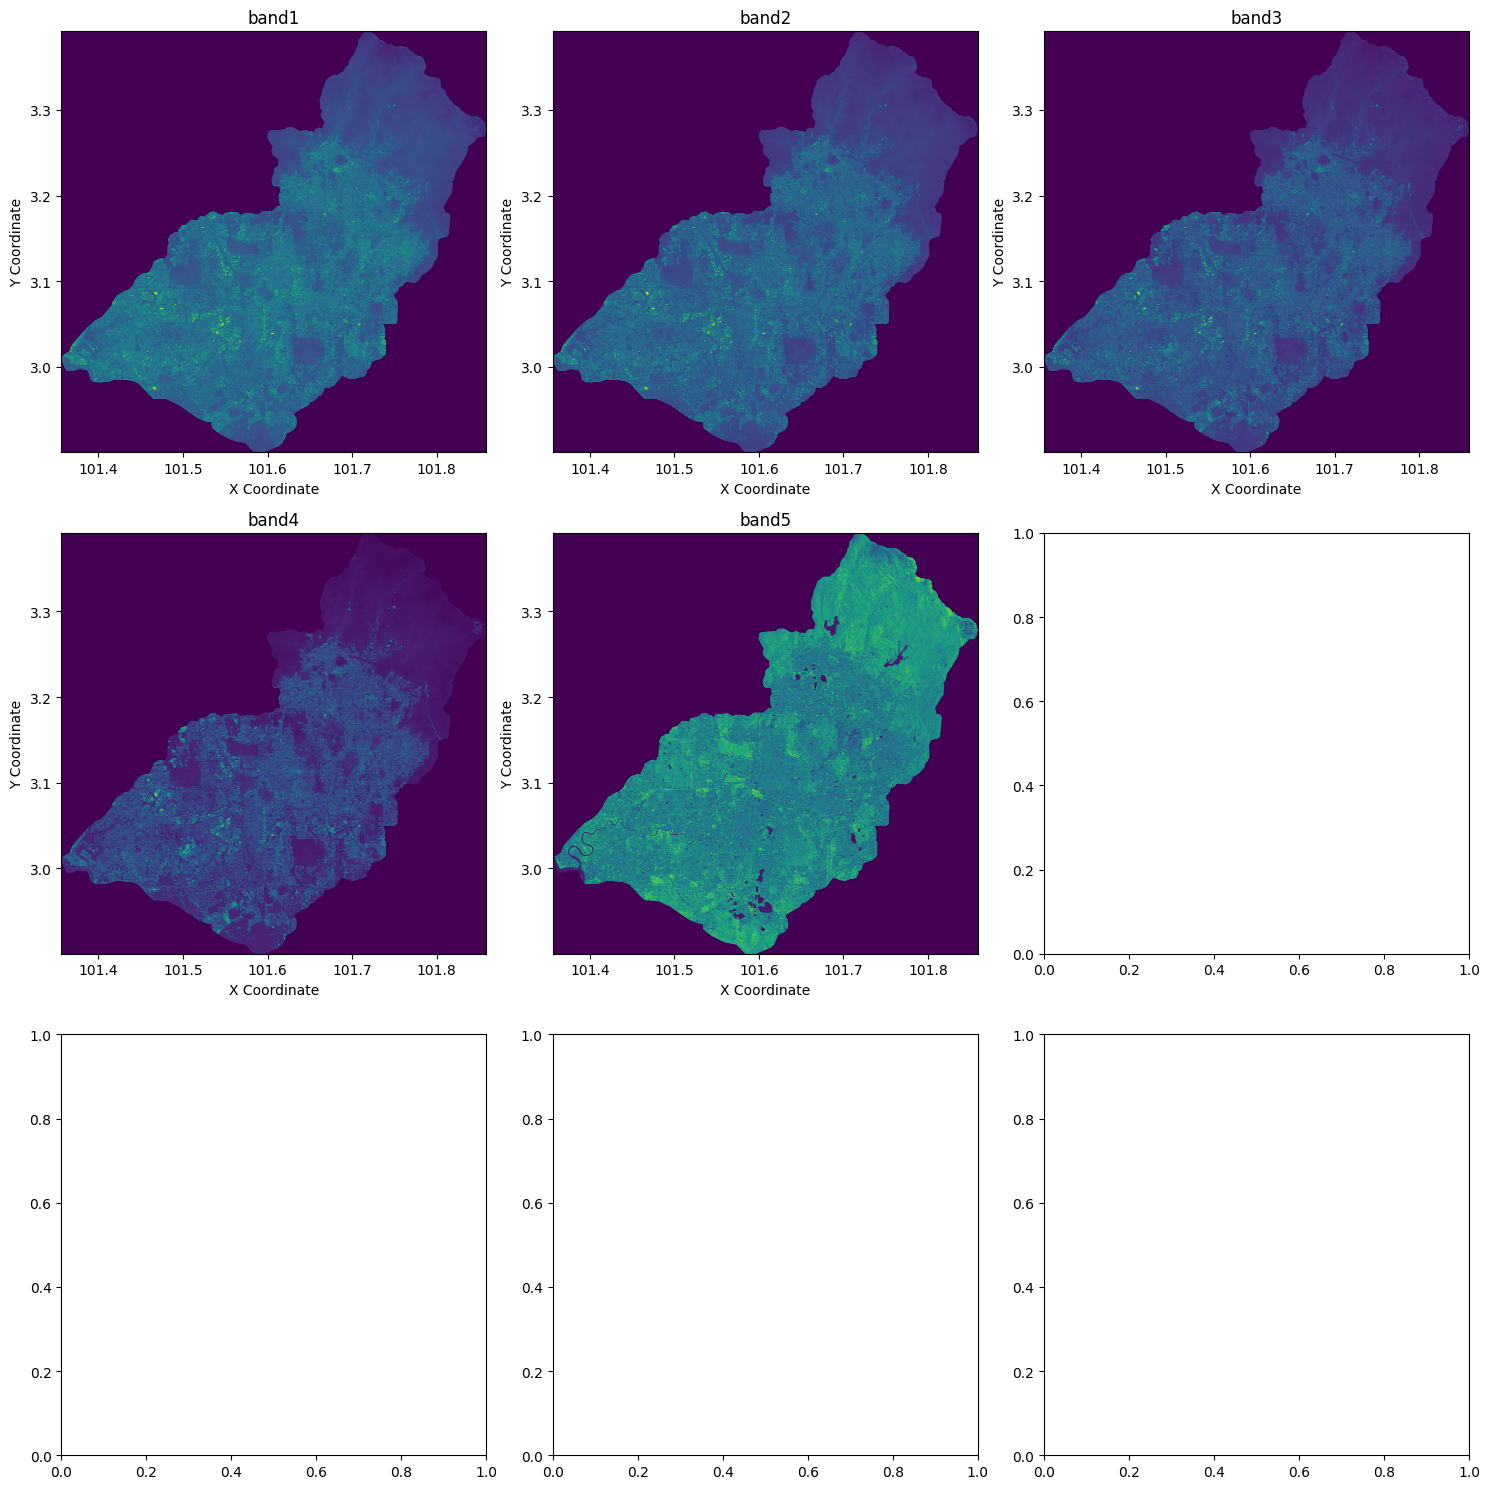

In [107]:
bands = ["band1", "band2", "band3", "band4", "band5"]  # Replace with actual names

fig, axes = plt.subplots(3, 3, figsize=(15, 15))  # Adjust grid size as needed
axes = axes.flatten()

for i, band in enumerate(bands):
    if i < len(axes):
        data_band = ds[band]
        axes[i].pcolormesh(y, x, data_band, shading='gouraud', cmap='viridis')
        axes[i].set_title(band)
        axes[i].set_xlabel("X Coordinate")
        axes[i].set_ylabel("Y Coordinate")

plt.tight_layout()
plt.show()

In [108]:
ds

<xarray.Dataset> Size: 68MB
Dimensions:  (lat: 1825, lon: 1867)
Coordinates:
  * lat      (lat) float64 15kB 2.9 2.9 2.901 2.901 ... 3.391 3.391 3.391 3.392
  * lon      (lon) float64 15kB 101.4 101.4 101.4 101.4 ... 101.9 101.9 101.9
Data variables:
    band1    (lat, lon) float32 14MB 0.06671 0.06671 0.06671 ... 0.06671 0.06671
    band2    (lat, lon) float32 14MB 0.04245 0.04245 0.04245 ... 0.04245 0.04245
    band3    (lat, lon) float32 14MB 0.02657 0.02657 0.02657 ... 0.02656 0.02656
    band4    (lat, lon) float32 14MB 0.0244 0.0244 0.0244 ... 0.0244 0.0244
    band5    (lat, lon) float32 14MB 0.006444 0.006444 ... 0.006443 0.006443

In [ ]:
# mirrored_ds = ds.isel(y=slice(None, None, -1))

In [ ]:
# mirrored_ds = mirrored_ds.assign_coords(
#     y=(-1 * mirrored_ds['y'].values) + mirrored_ds['y'].values[-1]
# )

In [ ]:
# x = mirrored_ds['x']
# y = mirrored_ds['y']

In [ ]:
# bands = ["band1", "band2", "band3", "band4", "band5", "band7"]  # Replace with actual names

# fig, axes = plt.subplots(3, 3, figsize=(15, 15))  # Adjust grid size as needed
# axes = axes.flatten()

# for i, band in enumerate(bands):
#     if i < len(axes):
#         data_band = mirrored_ds[band]
#         axes[i].pcolormesh(x, y, data_band, shading='auto', cmap='viridis')
#         axes[i].set_title(band)
#         axes[i].set_xlabel("X Coordinate")
#         axes[i].set_ylabel("Y Coordinate")

# plt.tight_layout()
# plt.show()

In [109]:
# Save to NetCDF file
output_file = "output_CA_LSTM_2024.nc"
ds.to_netcdf(output_file)

In [ ]:
%cd /kaggle/working

In [ ]:
from IPython.display import FileLink
FileLink(r'output_CA_LSTM_03.nc')